<link rel="stylesheet" href="../../styles.css">
<div class="note">

<h1>Overfitting</h1>

<img src="../../assets/dudl-04-overfitting.png">
<p>A model is overfitted if it fits tightly the training data and fails to fit new data. Overfitted models fail to encapsulate the underlying nature of the domain, instead it encapsulates the noise too heavily.</p>
<p>How can we tell if we are overfitting the model? If the model is 1 or 2 dimensional, we can visualize it, but in higher dimensions it is not practical, or even possible. In these cases we need to use statistical analysis:
<ul>
<li>cross-validation</li>
<li>regularization</li>
</ul>
Overfirring can be caused by the researcher, more specifically by the criteria the researcher uses for cleaning and organizing the data-
</p>
<h2>Cross-validation</h2>
<p>Cross-validation refers to the practice of separating the data to training, development and test datasets.<br>We train the data on the training set, and then use the development and test sets for validating the model.<br>Typically 80-90% of the data is the training data, the rest is the test sets.</p>
<p>After the training is done, we try it on the dev set without any backpropagation. If we are not satisfied, we tune the model and start again. Once we are satisfied we apply the model to the test set.</p>
<p>K-fold cross-validation: We separate a training and a test set. After training and testing the model, we choose another chunk of the data for test set, and train the model again. We repeat this "k" times.</p>

<p>When we use cross-validation the underlying assumption is that the training data and the test data are independent and do not correlate.</p>
<h2>Cross-validation using manual particioning</h2>
</div>

In [99]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
iris = sns.load_dataset('iris')
data = torch.tensor(iris[iris.columns[0:4]].values).float()

labels = torch.zeros(len(data), dtype=torch.long)
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2

propTraining = 0.8
ntraining = int(len(data)*propTraining)
trainTestBool = np.zeros(len(labels), dtype=bool)
trainTestBool[range(ntraining)] = True

In [101]:
# The average will tell about the ratio of different species in the different sets. The dataset appears to be skewed because the order is not randomized.
print(f'Average of data:          {torch.mean(labels.float())}')
print(f'Average of training data: {torch.mean(labels[trainTestBool].float())}')
print(f'Average of test data:     {torch.mean(labels[~trainTestBool].float())}')

Average of data:          1.0
Average of training data: 0.75
Average of test data:     2.0


In [102]:
itemsToUseForTraining = np.random.choice(range(len(labels)), ntraining, replace=False)
trainTestBool = np.zeros(len(labels), dtype=bool)
trainTestBool[itemsToUseForTraining] = True

print(f'Average of data:          {torch.mean(labels.float())}')
print(f'Average of training data: {torch.mean(labels[trainTestBool].float())}')
print(f'Average of test data:     {torch.mean(labels[~trainTestBool].float())}')

Average of data:          1.0
Average of training data: 1.0
Average of test data:     1.0


In [103]:
ANNiris = nn.Sequential(
    nn.Linear(4, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

lossFunction = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(ANNiris.parameters(), lr=0.01)

In [104]:
epochs = 1_000

losses = torch.zeros(epochs)
ongoingAccuracy = []
for i in range(epochs):
    yHat = ANNiris(data[trainTestBool,:])

    ongoingAccuracy.append(100*torch.mean((torch.argmax(yHat,axis=1) == labels[trainTestBool]).float()))

    loss = lossFunction(yHat, labels[trainTestBool])
    losses[i] = loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [105]:
predictions = ANNiris(data[trainTestBool,:])
trainAccuracy = 100 * torch.mean( (torch.argmax(predictions,axis=1) == labels[trainTestBool]).float() )

predictions = ANNiris(data[~trainTestBool,:])
testAccuracy = 100 * torch.mean( (torch.argmax(predictions,axis=1) == labels[~trainTestBool]).float() )

print(f'trainAccuracy={trainAccuracy} %')
print(f'testAccuracy= {testAccuracy} %')

trainAccuracy=97.5 %
testAccuracy= 96.66666412353516 %


<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Mini-batch training</h2>
<p>Mini-batch training refers to the process of partitioning the dataset and training the model on the partitions one by one. This sort of training can decrease the training time and the computation needs.</p>

<h2>Cross-validation using DataLoader</h2>
</div>

In [106]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

iris = sns.load_dataset('iris')
data = torch.tensor(iris[iris.columns[0:4]].values).float()

labels = torch.zeros(data.shape[0])
species = np.unique(iris[iris.columns[4]])
index = 0
for s in species:
    labels[np.where(iris[iris.columns[4]] == s)] = index
    index += 1

In [107]:
fakeData = np.tile(np.array([1, 2, 3, 4]), (10, 1)) + np.tile(10 * np.arange(1, 11), (4, 1)).T
fakeLabels = np.arange(10)>4
print(fakeData)
print('')
print(fakeLabels)

[[ 11  12  13  14]
 [ 21  22  23  24]
 [ 31  32  33  34]
 [ 41  42  43  44]
 [ 51  52  53  54]
 [ 61  62  63  64]
 [ 71  72  73  74]
 [ 81  82  83  84]
 [ 91  92  93  94]
 [101 102 103 104]]

[False False False False False  True  True  True  True  True]


In [108]:
fakeDataLoader = DataLoader(fakeData, shuffle=True)
print(fakeDataLoader)
print(fakeDataLoader.batch_size)
print('')

for index,sample in enumerate(fakeDataLoader):
    print(index, sample, sample.shape)

1

0 tensor([[101, 102, 103, 104]]) torch.Size([1, 4])
1 tensor([[31, 32, 33, 34]]) torch.Size([1, 4])
2 tensor([[21, 22, 23, 24]]) torch.Size([1, 4])
3 tensor([[41, 42, 43, 44]]) torch.Size([1, 4])
4 tensor([[11, 12, 13, 14]]) torch.Size([1, 4])
5 tensor([[91, 92, 93, 94]]) torch.Size([1, 4])
6 tensor([[61, 62, 63, 64]]) torch.Size([1, 4])
7 tensor([[81, 82, 83, 84]]) torch.Size([1, 4])
8 tensor([[51, 52, 53, 54]]) torch.Size([1, 4])
9 tensor([[71, 72, 73, 74]]) torch.Size([1, 4])


In [109]:
# we need to create an object that contains both the data and the labels
fakeDataSet = torch.utils.data.TensorDataset(torch.tensor(fakeData), torch.tensor(fakeLabels))
fakeDataSet.tensors

(tensor([[ 11,  12,  13,  14],
         [ 21,  22,  23,  24],
         [ 31,  32,  33,  34],
         [ 41,  42,  43,  44],
         [ 51,  52,  53,  54],
         [ 61,  62,  63,  64],
         [ 71,  72,  73,  74],
         [ 81,  82,  83,  84],
         [ 91,  92,  93,  94],
         [101, 102, 103, 104]]),
 tensor([False, False, False, False, False,  True,  True,  True,  True,  True]))

In [110]:
fakeDataLoader = DataLoader(fakeDataSet, shuffle=True)
for dat,lab in fakeDataLoader:
    print(dat)
    print(lab)
    print(' ')

tensor([[51, 52, 53, 54]])
tensor([False])
 
tensor([[31, 32, 33, 34]])
tensor([False])
 
tensor([[81, 82, 83, 84]])
tensor([True])
 
tensor([[101, 102, 103, 104]])
tensor([True])
 
tensor([[71, 72, 73, 74]])
tensor([True])
 
tensor([[91, 92, 93, 94]])
tensor([True])
 
tensor([[21, 22, 23, 24]])
tensor([False])
 
tensor([[41, 42, 43, 44]])
tensor([False])
 
tensor([[11, 12, 13, 14]])
tensor([False])
 
tensor([[61, 62, 63, 64]])
tensor([True])
 


In [111]:
trainData, testData, trainLabel, testLabel = train_test_split(fakeData, fakeLabels, test_size=0.2)

trainData = torch.utils.data.TensorDataset(torch.tensor(trainData), torch.tensor(trainLabel))
testData = torch.utils.data.TensorDataset(torch.tensor(testData), torch.tensor(testLabel))

trainLoader = DataLoader(trainData, batch_size=4)
testLoader = DataLoader(testData)

print('Training data')
for batch, label in trainLoader:
    print(batch, label)

print('')

print('Test data')
for batch, label in testLoader:
    print(batch, label)

Training data
tensor([[ 71,  72,  73,  74],
        [101, 102, 103, 104],
        [ 41,  42,  43,  44],
        [ 81,  82,  83,  84]]) tensor([ True,  True, False,  True])
tensor([[21, 22, 23, 24],
        [11, 12, 13, 14],
        [51, 52, 53, 54],
        [91, 92, 93, 94]]) tensor([False, False, False,  True])

Test data
tensor([[61, 62, 63, 64]]) tensor([True])
tensor([[31, 32, 33, 34]]) tensor([False])


In [112]:
trainData, testData, trainLabels, testLabels = train_test_split(data, labels, train_size=0.8)

trainData = torch.utils.data.TensorDataset(trainData, trainLabels)
testData = torch.utils.data.TensorDataset(testData, testLabels)

trainLoader = DataLoader(trainData, batch_size=12)
testLoader = DataLoader(testData, testData.tensors[0].shape[0])

In [113]:
ANNmodel = nn.Sequential(
    nn.Linear(4, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

lossFunction = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(ANNmodel.parameters(), lr=0.01)

In [114]:
numberOfEpochs = 500

trainAccuracy = []
testAccuracy = []

for i in range(numberOfEpochs):
    batchAccuracy = []
    for dat,lab in trainLoader:
        yHat = ANNmodel(dat)

        loss = lossFunction(yHat.float(), lab.long())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchAccuracy.append( torch.mean((torch.argmax(yHat, axis=1) == lab).float()).item() )
    
    trainAccuracy.append(np.mean(batchAccuracy))

    testDat,testLab = next(iter(testLoader))
    predictedLabels = torch.argmax(ANNmodel(testDat), axis=1)
    testAccuracy.append( 100*torch.mean((predictedLabels == testLab).float()).item() )

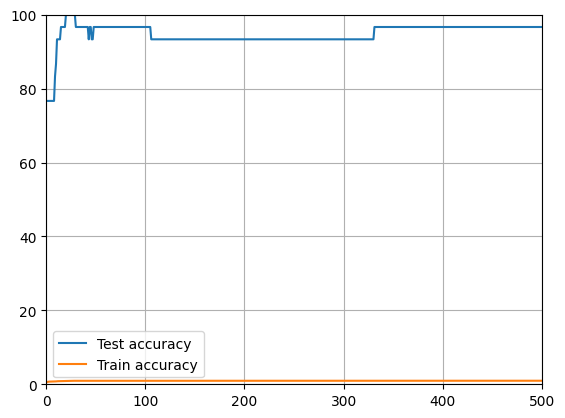

In [123]:
plt.plot(testAccuracy)
plt.plot(trainAccuracy)
plt.legend(['Test accuracy', 'Train accuracy'])
plt.grid()
plt.xlim([0, numberOfEpochs])
plt.ylim([0, 100])
plt.show()